In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# World Cup Expansion to 48 Teams Data Exploration

## ELO

In [3]:
elo_df = pd.read_csv('../data/processed/elo_at_wc_entry.csv')
elo_df.head()

,tournament_id,team,first_match_date,elo_at_entry,year
0,WC-1930,Argentina,1930-07-15,1794.42,1930
1,WC-1930,Belgium,1930-07-13,1459.93,1930
2,WC-1930,Bolivia,1930-07-17,1307.88,1930
3,WC-1930,Brazil,1930-07-14,1589.70,1930
4,WC-1930,Chile,1930-07-16,1376.82,1930


In [4]:
elo_df[elo_df['year'] == 2022].sort_values('elo_at_entry', ascending=False).head(10)

,tournament_id,team,first_match_date,elo_at_entry,year
429,WC-2022,Brazil,2022-11-24,2229.09,2022
426,WC-2022,Argentina,2022-11-22,2188.30,2022
452,WC-2022,Spain,2022-11-23,2097.70,2022
444,WC-2022,Netherlands,2022-11-21,2085.78,2022
428,WC-2022,Belgium,2022-11-23,2063.09,2022
446,WC-2022,Portugal,2022-11-24,2054.53,2022
437,WC-2022,France,2022-11-22,2045.40,2022
438,WC-2022,Germany,2022-11-23,2016.16,2022
434,WC-2022,Denmark,2022-11-22,2016.14,2022
456,WC-2022,Uruguay,2022-11-24,2003.77,2022


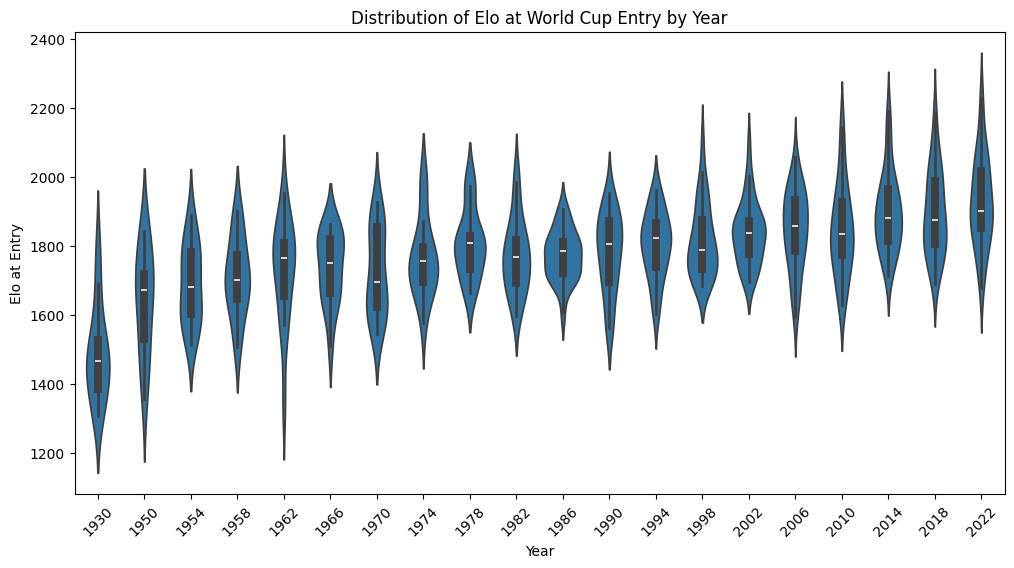

In [ ]:
# Plot violin plot of Elo at entry by year
plt.figure(figsize=(12, 6))
sns.violinplot(x='year', y='elo_at_entry', data=elo_df)
plt.title('Distribution of Elo at World Cup Entry by Year')
plt.xlabel('Year')
plt.ylabel('Elo at Entry')
plt.xticks(rotation=45)
plt.show()

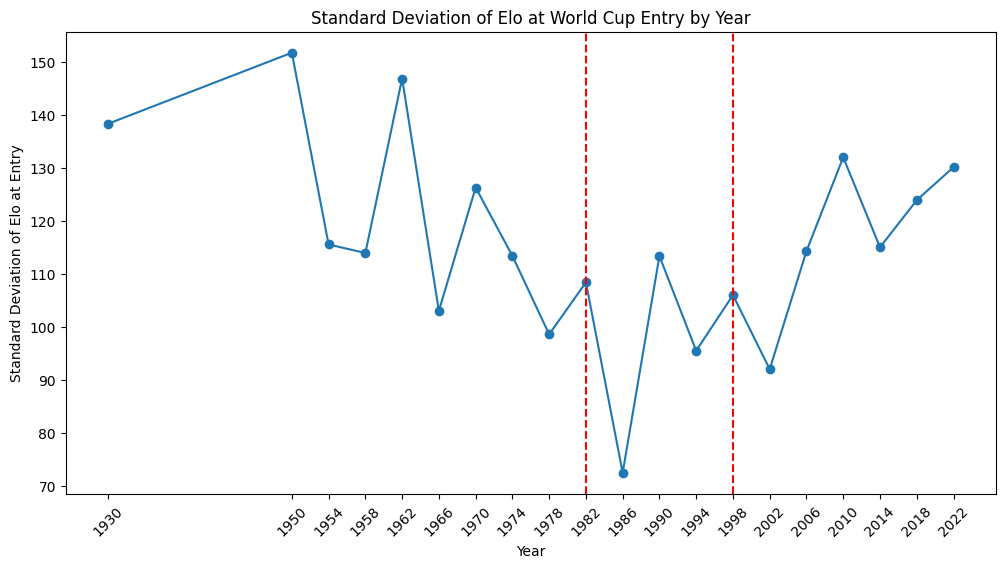

In [39]:
# Plot elo standard deviation at entry by year
std_by_year = elo_df.groupby('year')['elo_at_entry'].std().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(std_by_year['year'], std_by_year['elo_at_entry'], marker='o')
plt.title('Standard Deviation of Elo at World Cup Entry by Year')
plt.xlabel('Year')
plt.ylabel('Standard Deviation of Elo at Entry')
plt.xticks(rotation=45)

# Show every tick on x-axis
plt.xticks(std_by_year['year'], rotation=45)

# Show vertical line at year 1998 and 1982
plt.axvline(x=1998, color='r', linestyle='--')
plt.axvline(x=1982, color='r', linestyle='--')

plt.show()

In [14]:
# Count number of teams per year
teams_per_year = elo_df.groupby('year')['team'].nunique().reset_index()
teams_per_year.columns = ['year', 'num_teams']
teams_per_year

,year,num_teams
0,1930,13
1,1950,13
2,1954,16
3,1958,16
4,1962,16
5,1966,16
6,1970,16
7,1974,16
8,1978,16
9,1982,24


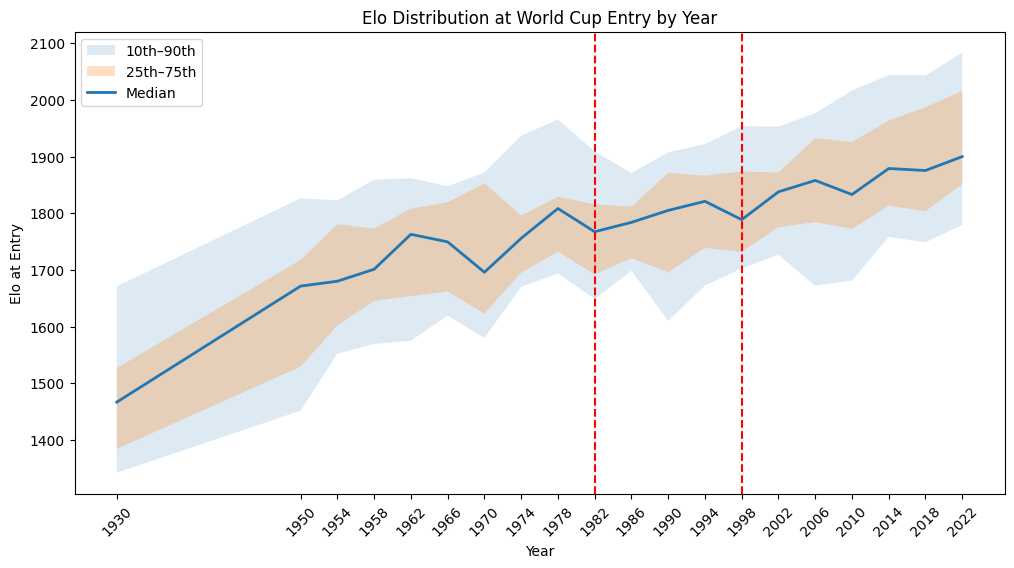

In [42]:
# Plot bottom 10% of Elo at entry by year
percentiles = elo_df.groupby('year')['elo_at_entry'].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).unstack()
percentiles.columns = ['p10', 'p25', 'p50', 'p75', 'p90']

plt.figure(figsize=(12, 6))
plt.fill_between(percentiles.index, percentiles['p10'], percentiles['p90'], alpha=0.15, label='10th–90th')
plt.fill_between(percentiles.index, percentiles['p25'], percentiles['p75'], alpha=0.25, label='25th–75th')
plt.plot(percentiles.index, percentiles['p50'], label='Median', linewidth=2)
plt.title('Elo Distribution at World Cup Entry by Year')
plt.xlabel('Year')
plt.ylabel('Elo at Entry')
plt.legend()
plt.xticks(rotation=45)

# Show every tick on x-axis
plt.xticks(percentiles.index, rotation=45)

# Show vertical line at year 1998 and 1982
plt.axvline(x=1998, color='r', linestyle='--')
plt.axvline(x=1982, color='r', linestyle='--')

plt.show()

## CIS

In [27]:
wc_cis_df = pd.read_csv('../data/processed/cis_by_tournament.csv')

wc_cis_df

,tournament_id,year,matches,mean_cis,median_cis,std_cis,mean_goal_diff,mean_elo_gap,draw_rate
0,WC-1930,1930,15,0.2944,0.2433,0.2302,2.4000,186.2920,0.0000
1,WC-1950,1950,22,0.3868,0.3856,0.2676,2.2727,152.4536,0.1364
2,WC-1954,1954,18,0.2902,0.1658,0.3133,3.3333,161.5100,0.1111
3,WC-1958,1958,27,0.5306,0.5031,0.2872,1.2963,150.5641,0.3704
4,WC-1962,1962,24,0.5017,0.4728,0.2445,1.5417,162.6354,0.2083
5,WC-1966,1966,24,0.5122,0.4647,0.2486,1.5000,137.7942,0.2083
6,WC-1970,1970,24,0.4799,0.5118,0.2402,1.4583,150.7396,0.2083
7,WC-1974,1974,30,0.4857,0.4788,0.3028,1.8333,133.5783,0.2667
8,WC-1978,1978,36,0.5280,0.5558,0.2475,1.4722,133.9019,0.2500
9,WC-1982,1982,48,0.5514,0.6088,0.2832,1.3958,129.5137,0.3333


In [28]:
match_cis_df = pd.read_csv('../data/processed/cis_by_match.csv')

match_cis_df

,tournament_id,tournament_name,year,match_id,match_date,group_name,home_team_name,away_team_name,home_team_score,away_team_score,goal_diff,home_elo,away_elo,elo_gap,scoreline_component,elo_weight,cis
0,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-01,1930-07-13,Group 1,France,Mexico,4,1,3,1333.58,1476.16,142.58,0.75,0.7778,0.1944
1,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-02,1930-07-13,Group 4,United States,Belgium,3,0,3,1477.25,1459.93,17.32,0.75,0.9730,0.2433
2,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-03,1930-07-14,Group 2,Yugoslavia,Brazil,2,1,1,1450.97,1589.70,138.73,0.25,0.7838,0.5878
3,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-04,1930-07-14,Group 3,Romania,Peru,3,1,2,1466.84,1384.36,82.48,0.50,0.8715,0.4357
4,WC-1930,1930 FIFA Men's World Cup,1930,M-1930-05,1930-07-15,Group 1,Argentina,France,1,0,1,1794.42,1333.58,460.84,0.25,0.5000,0.3750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
713,WC-2022,2022 FIFA Men's World Cup,2022,M-2022-44,2022-12-01,Group E,Japan,Spain,2,1,1,1895.26,2097.70,202.44,0.25,0.6845,0.5134
714,WC-2022,2022 FIFA Men's World Cup,2022,M-2022-45,2022-12-02,Group H,Ghana,Uruguay,0,2,2,1678.56,2003.77,325.21,0.50,0.5000,0.2500
715,WC-2022,2022 FIFA Men's World Cup,2022,M-2022-46,2022-12-02,Group H,South Korea,Portugal,2,1,1,1886.27,2054.53,168.26,0.25,0.7378,0.5533
716,WC-2022,2022 FIFA Men's World Cup,2022,M-2022-47,2022-12-02,Group G,Cameroon,Brazil,1,0,1,1716.32,2229.09,512.77,0.25,0.5000,0.3750


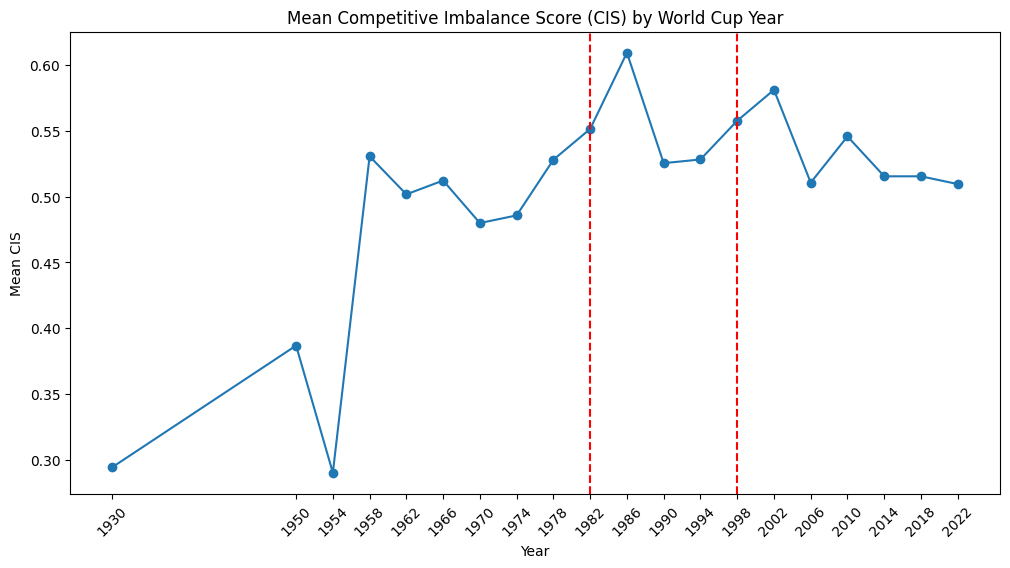

In [38]:
# Plot mean CIS by year
plt.figure(figsize=(12, 6))
plt.plot(wc_cis_df['year'], wc_cis_df['mean_cis'], marker='o')
plt.title('Mean Competitive Imbalance Score (CIS) by World Cup Year')
plt.xlabel('Year')
plt.ylabel('Mean CIS')
plt.xticks(rotation=45)

# Show every tick on x-axis
plt.xticks(wc_cis_df['year'], rotation=45)

# Show vertical line at year 1998 and 1982
plt.axvline(x=1998, color='r', linestyle='--')
plt.axvline(x=1982, color='r', linestyle='--')
plt.show()

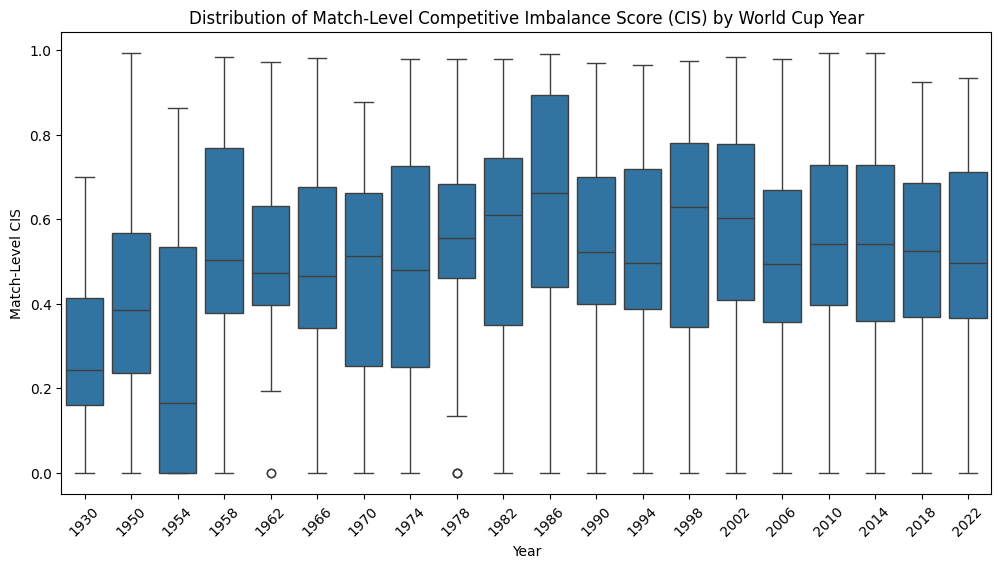

In [31]:
#  Plot distribution of match-level CIS by year
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='cis', data=match_cis_df)
plt.title('Distribution of Match-Level Competitive Imbalance Score (CIS) by World Cup Year')
plt.xlabel('Year')
plt.ylabel('Match-Level CIS')
plt.xticks(rotation=45)
plt.show()

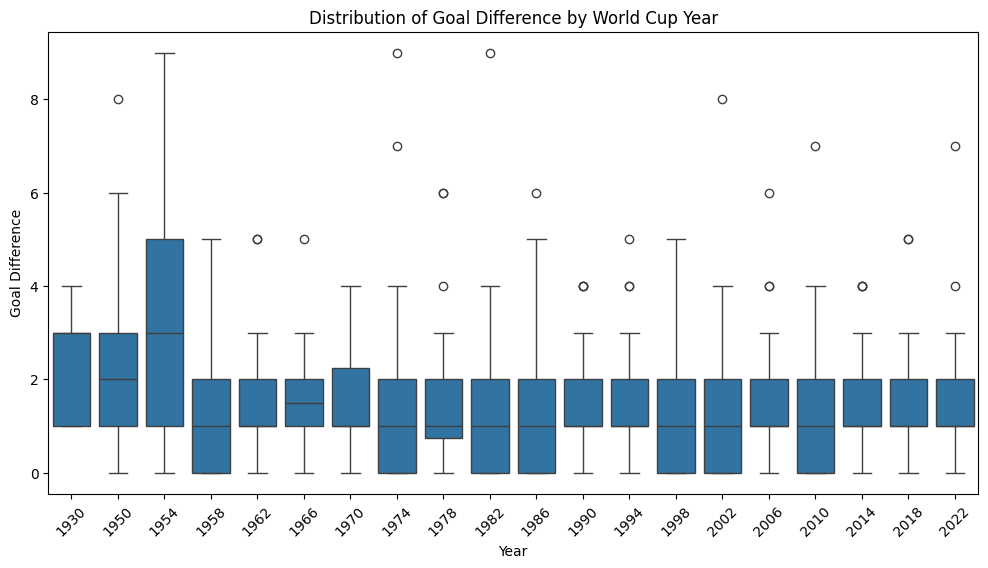

In [32]:
# Plot goal difference distribution by year
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='goal_diff', data=match_cis_df)
plt.title('Distribution of Goal Difference by World Cup Year')
plt.xlabel('Year')
plt.ylabel('Goal Difference')
plt.xticks(rotation=45)
plt.show()

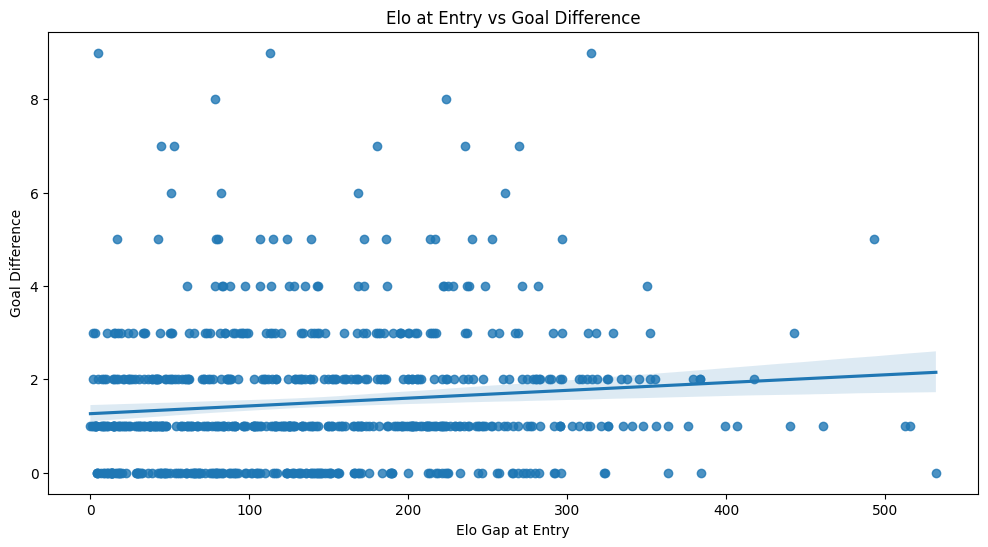

In [36]:
# Plot elo vs score difference scatter plot with regression line
plt.figure(figsize=(12, 6))
sns.regplot(x='elo_gap', y='goal_diff', data=match_cis_df)
plt.title('Elo at Entry vs Goal Difference')
plt.xlabel('Elo Gap at Entry')
plt.ylabel('Goal Difference')
plt.show()

## Group Stage Analysis

In [68]:
group_stage_df = pd.read_csv('../data/processed/group_standings.csv')
group_stage_df.head()

# Join group stage data with elo at entry data to get elo at entry for each team in group stage
group_stage_elo_df = group_stage_df.merge(elo_df[['year', 'team', 'elo_at_entry']], left_on=['year', 'team'], right_on=['year', 'team'], how='left')
group_stage_elo_df.head()

# Pivot group_stage_elo_df to get elo at entry for each team in group stage in separate columns, ranked by elo at entry
group_stage_elo_pivot = group_stage_elo_df.pivot_table(index=['year', 'group_name'], columns=group_stage_elo_df.groupby(['year', 'group_name'])['elo_at_entry'].rank(ascending=False), values='elo_at_entry').reset_index()
# group_stage_elo_pivot.columns = ['year', 'group_name', 'elo_at_entry_1', 'elo_at_entry_2', 'elo_at_entry_3', 'elo_at_entry_4']
group_stage_elo_pivot.head()  


elo_at_entry,year,group_name,1.0,2.0,3.0,4.0,5.0,6.0
0,1930,Group 1,1794.42,1476.16,1376.82,1333.58,NaN,NaN
1,1930,Group 2,1589.70,1450.97,1307.88,NaN,NaN,NaN
2,1930,Group 3,1691.64,1466.84,1384.36,NaN,NaN,NaN
3,1930,Group 4,1527.09,1477.25,1459.93,NaN,NaN,NaN
4,1950,Final Round,1795.47,1713.45,1671.61,1580.06,NaN,NaN


In [47]:
# Group-level Elo summary
group_elo_summary = group_stage_elo_df.groupby(['year', 'tournament_id', 'group_name']).agg(
    team_count    = ('team', 'count'),
    mean_elo      = ('elo_at_entry', 'mean'),
    std_elo       = ('elo_at_entry', 'std'),
    min_elo       = ('elo_at_entry', 'min'),
    max_elo       = ('elo_at_entry', 'max'),
).reset_index()

group_elo_summary['elo_range'] = group_elo_summary['max_elo'] - group_elo_summary['min_elo']

group_elo_summary = group_elo_summary.round(1)
group_elo_summary

,year,tournament_id,group_name,team_count,mean_elo,std_elo,min_elo,max_elo,elo_range
0,1930,WC-1930,Group 1,4,1495.2,208.2,1333.6,1794.4,460.8
1,1930,WC-1930,Group 2,3,1449.5,140.9,1307.9,1589.7,281.8
2,1930,WC-1930,Group 3,3,1514.3,159.0,1384.4,1691.6,307.3
3,1930,WC-1930,Group 4,3,1488.1,34.9,1459.9,1527.1,67.2
4,1950,WC-1950,Final Round,4,1690.1,89.6,1580.1,1795.5,215.4
...,...,...,...,...,...,...,...,...,...
116,2022,WC-2022,Group D,4,1921.0,128.2,1793.1,2045.4,252.3
117,2022,WC-2022,Group E,4,1967.7,109.2,1861.6,2097.7,236.1
118,2022,WC-2022,Group F,4,1946.1,92.1,1857.8,2063.1,205.3
119,2022,WC-2022,Group G,4,1964.4,209.6,1716.3,2229.1,512.8


In [70]:
# Group of death per tournament = highest mean Elo
group_of_death = group_elo_summary.loc[
    group_elo_summary.groupby('year')['mean_elo'].idxmax()
][['year', 'group_name', 'mean_elo', 'std_elo', 'elo_range']].reset_index(drop=True)

group_of_death.columns = ['year', 'group_of_death', 'mean_elo', 'std_elo', 'elo_range']
group_of_death# For each group, rank teams by Elo and extract the gap between 2nd and 3rd
def elo_gap_2nd_3rd(group_df):
    sorted_teams = group_df.sort_values('elo_at_entry', ascending=False).reset_index(drop=True)
    if len(sorted_teams) < 3:
        return pd.Series({'team_2nd': None, 'elo_2nd': None, 'team_3rd': None, 'elo_3rd': None, 'gap_2nd_3rd': None})
    return pd.Series({
        'team_2nd':    sorted_teams.loc[1, 'team'],
        'elo_2nd':     sorted_teams.loc[1, 'elo_at_entry'],
        'team_3rd':    sorted_teams.loc[2, 'team'],
        'elo_3rd':     sorted_teams.loc[2, 'elo_at_entry'],
        'gap_2nd_3rd': sorted_teams.loc[1, 'elo_at_entry'] - sorted_teams.loc[2, 'elo_at_entry'],
    })

group_death_metric = (
    group_stage_elo_df
    .groupby(['year', 'tournament_id', 'group_name'])
    .apply(elo_gap_2nd_3rd)
    .reset_index()
    .round(1)
)

# Group of death = smallest gap between 2nd and 3rd
group_of_death = group_death_metric.loc[
    group_death_metric.groupby('year')['gap_2nd_3rd'].idxmin()
][['year', 'group_name', 'team_2nd', 'elo_2nd', 'team_3rd', 'elo_3rd', 'gap_2nd_3rd']].reset_index(drop=True)

group_of_death

,year,group_name,team_2nd,elo_2nd,team_3rd,elo_3rd,gap_2nd_3rd
0,1930,Group 4,United States,1477.2,Belgium,1459.9,17.3
1,1950,Group 3,Paraguay,1717.8,Sweden,1713.4,4.3
2,1954,Group 3,Austria,1681.6,Scotland,1678.8,2.8
3,1958,Group 1,Germany,1749.6,Czechoslovakia,1717.0,32.7
4,1962,Group 3,Czechoslovakia,1802.6,Spain,1794.1,8.5
5,1966,Group 1,Mexico,1764.2,Uruguay,1703.4,60.8
6,1970,Group 1,Belgium,1641.5,Mexico,1631.0,10.5
7,1974,Group 2,DR Congo,1798.8,Yugoslavia,1793.8,5.0
8,1978,Group B,Argentina,1831.0,Poland,1821.1,9.9
9,1982,Group 4,Austria,1806.4,Czechoslovakia,1785.3,21.1


In [72]:
# Group of death = highest minimum Elo (strongest weakest team)
group_min_elo = (
    group_stage_elo_df
    .groupby(['year', 'tournament_id', 'group_name'])
    .agg(
        min_elo  = ('elo_at_entry', 'min'),
        mean_elo = ('elo_at_entry', 'mean'),
        teams    = ('team', lambda x: ', '.join(sorted(x)))
    )
    .reset_index()
    .round(1)
)

group_of_death = group_min_elo.loc[
    group_min_elo.groupby('year')['min_elo'].idxmax()
][['year', 'group_name', 'min_elo', 'mean_elo', 'teams']].reset_index(drop=True)

group_of_death

,year,group_name,min_elo,mean_elo,teams
0,1930,Group 4,1459.9,1488.1,"Belgium, Paraguay, United States"
1,1950,Group 3,1713.4,1755.2,"Italy, Paraguay, Sweden"
2,1954,Group 1,1612.5,1713.2,"Brazil, France, Mexico, Yugoslavia"
3,1958,Group 4,1676.9,1765.8,"Austria, Brazil, England, Russia"
4,1962,Group 3,1672.1,1805.3,"Brazil, Czechoslovakia, Mexico, Spain"
5,1966,Group 3,1659.6,1748.7,"Brazil, Bulgaria, Hungary, Portugal"
6,1970,Group 3,1649.2,1816.4,"Brazil, Czechoslovakia, England, Romania"
7,1974,Group B,1755.9,1821.6,"Germany, Poland, Sweden, Yugoslavia"
8,1978,Group 1,1770.4,1802.3,"Argentina, France, Hungary, Italy"
9,1982,Group 6,1712.8,1835.5,"Brazil, New Zealand, Russia, Scotland"


In [73]:
group_composite = (
    group_stage_elo_df
    .groupby(['year', 'tournament_id', 'group_name'])
    .agg(
        min_elo  = ('elo_at_entry', 'min'),
        max_elo  = ('elo_at_entry', 'max'),
        mean_elo = ('elo_at_entry', 'mean'),
        std_elo  = ('elo_at_entry', 'std'),
        teams    = ('team', lambda x: ', '.join(x.sort_values().values))
    )
    .reset_index()
    .round(1)
)

# Composite: average of max and min Elo, normalised within each tournament
# High score = strong best team AND strong worst team
group_composite['god_score'] = (group_composite['max_elo'] + group_composite['min_elo']) / 2

# Normalise within each tournament so years are comparable
group_composite['god_score_norm'] = (
    group_composite.groupby('year')['god_score']
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
).round(3)

group_of_death = group_composite.loc[
    group_composite.groupby('year')['god_score_norm'].idxmax()
][['year', 'group_name', 'max_elo', 'min_elo', 'mean_elo', 'std_elo', 'god_score_norm', 'teams']].reset_index(drop=True)

group_of_death

,year,group_name,max_elo,min_elo,mean_elo,std_elo,god_score_norm,teams
0,1930,Group 1,1794.4,1333.6,1495.2,208.2,1.0,"Argentina, Chile, France, Mexico"
1,1950,Group 3,1834.3,1713.4,1755.2,68.5,1.0,"Italy, Paraguay, Sweden"
2,1954,Group 1,1856.2,1612.5,1713.2,119.8,1.0,"Brazil, France, Mexico, Yugoslavia"
3,1958,Group 4,1829.2,1676.9,1765.8,71.9,1.0,"Austria, Brazil, England, Russia"
4,1962,Group 3,1952.4,1672.1,1805.3,114.8,1.0,"Brazil, Czechoslovakia, Mexico, Spain"
5,1966,Group 3,1859.8,1659.6,1748.7,102.8,1.0,"Brazil, Bulgaria, Hungary, Portugal"
6,1970,Group 3,1926.0,1649.2,1816.4,121.4,1.0,"Brazil, Czechoslovakia, England, Romania"
7,1974,Group B,1980.0,1755.9,1821.6,107.0,1.0,"Germany, Poland, Sweden, Yugoslavia"
8,1978,Group A,1986.0,1737.4,1878.0,121.4,1.0,"Austria, Germany, Italy, Netherlands"
9,1982,Group 6,1984.6,1712.8,1835.5,136.2,1.0,"Brazil, New Zealand, Russia, Scotland"


In [71]:
group_stage_elo_df[(group_stage_elo_df['year']==2022)]

,tournament_id,year,group_name,team,played,won,drawn,lost,goals_for,goals_against,points,goal_diff,group_rank,elo_at_entry
454,WC-2022,2022,Group A,Netherlands,3,2,1,0,5,1,7,4,1,2085.78
455,WC-2022,2022,Group A,Senegal,3,2,0,1,5,4,6,1,2,1795.86
456,WC-2022,2022,Group A,Ecuador,3,1,1,1,4,3,4,1,3,1902.41
457,WC-2022,2022,Group A,Qatar,3,0,0,3,1,7,0,-6,4,1778.19
458,WC-2022,2022,Group B,England,3,2,1,0,9,2,7,7,1,1973.35
459,WC-2022,2022,Group B,United States,3,1,2,0,2,1,5,1,2,1897.87
460,WC-2022,2022,Group B,Iran,3,1,0,2,4,7,3,-3,3,1894.77
461,WC-2022,2022,Group B,Wales,3,0,1,2,1,6,1,-5,4,1832.70
462,WC-2022,2022,Group C,Argentina,3,2,0,1,5,2,6,3,1,2188.30
463,WC-2022,2022,Group C,Poland,3,1,1,1,2,2,4,0,2,1862.38


In [76]:
import numpy as np

# ---------------------------------------------------------------------------
# Thresholds
# ---------------------------------------------------------------------------
STRONG_THRESHOLD = np.percentile(elo_df['elo_at_entry'].dropna(), 67)  # 1856 — fixed historical bar
print(f'Strong threshold (67th percentile historically): {STRONG_THRESHOLD:.0f}')

# Tournament median floats per year
tournament_median = (
    elo_df.groupby('year')['elo_at_entry']
    .median()
    .reset_index()
    .rename(columns={'elo_at_entry': 'tournament_median'})
)

# ---------------------------------------------------------------------------
# Build group profile
# ---------------------------------------------------------------------------
group_profile = (
    group_stage_elo_df
    .merge(tournament_median, on='year')
    .groupby(['year', 'tournament_id', 'group_name'])
    .apply(lambda g: pd.Series({
        'teams':           ', '.join(g.sort_values('elo_at_entry', ascending=False)['team'].values),
        'mean_elo':        g['elo_at_entry'].mean(),
        'min_elo':         g['elo_at_entry'].min(),
        'max_elo':         g['elo_at_entry'].max(),
        'strong_teams':    (g['elo_at_entry'] >= STRONG_THRESHOLD).sum(),
        'competitive_teams': (
            (g['elo_at_entry'] >= g['tournament_median']) &
            (g['elo_at_entry'] < STRONG_THRESHOLD)
        ).sum(),
        'tournament_median': g['tournament_median'].iloc[0],
    }))
    .reset_index()
    .round(1)
)

# ---------------------------------------------------------------------------
# Classify each group
# ---------------------------------------------------------------------------
def classify_group(row):
    if row['strong_teams'] >= 3 and row['competitive_teams'] >= 1:
        return 'Extreme Group of Death'
    elif row['strong_teams'] >= 3:
        return 'Group of Death'
    else:
        return 'Standard'

group_profile['classification'] = group_profile.apply(classify_group, axis=1)

# ---------------------------------------------------------------------------
# Results
# ---------------------------------------------------------------------------
god = group_profile[group_profile['classification'] != 'Standard'].sort_values('year')
print(f'\nGroups of Death across all tournaments:')
print(god[['year', 'group_name', 'classification', 'strong_teams', 'competitive_teams', 'teams']].to_string(index=False))



Strong threshold (67th percentile historically): 1856

Groups of Death across all tournaments:
 year group_name classification  strong_teams  competitive_teams                                       teams
 2002    Group F Group of Death             3                  0         Argentina, England, Sweden, Nigeria
 2002    Group G Group of Death             3                  0             Italy, Mexico, Croatia, Ecuador
 2006    Group D Group of Death             3                  0              Portugal, Iran, Mexico, Angola
 2006    Group E Group of Death             3                  0 Czech Republic, Italy, United States, Ghana
 2006    Group F Group of Death             3                  0           Brazil, Australia, Japan, Croatia
 2010    Group A Group of Death             3                  0       Mexico, France, Uruguay, South Africa
 2014    Group G Group of Death             3                  0     Germany, Portugal, United States, Ghana
 2014    Group E Group of Death  

In [77]:
# Dedup — within each year and classification, keep the group with the highest mean Elo of top 3 teams
group_profile['mean_elo_top4'] = (
    group_stage_elo_df
    .merge(tournament_median, on='year')
    .groupby(['year', 'tournament_id', 'group_name'])
    .apply(lambda g: g.nlargest(4, 'elo_at_entry')['elo_at_entry'].mean())
    .reset_index(drop=True)
)

god_deduped = (
    group_profile[group_profile['classification'] != 'Standard']
    .sort_values('mean_elo_top4', ascending=False)
    .drop_duplicates(subset=['year', 'classification'])
    .sort_values(['year', 'classification'])
)

print(god_deduped[['year', 'group_name', 'classification', 'strong_teams', 
                    'competitive_teams', 'mean_elo_top4', 'teams']].to_string(index=False))

 year group_name classification  strong_teams  competitive_teams  mean_elo_top4                                 teams
 2002    Group F Group of Death             3                  0      1901.6125   Argentina, England, Sweden, Nigeria
 2006    Group F Group of Death             3                  0      1911.3825     Brazil, Australia, Japan, Croatia
 2010    Group A Group of Death             3                  0      1847.8600 Mexico, France, Uruguay, South Africa
 2014    Group B Group of Death             3                  0      1979.4100  Spain, Netherlands, Chile, Australia
 2018    Group B Group of Death             3                  0      1952.3375        Spain, Portugal, Iran, Morocco
 2022    Group E Group of Death             4                  0      1967.6875     Spain, Germany, Japan, Costa Rica


In [55]:
# Most lopsided group per tournament = highest elo_range
mismatch_group = group_elo_summary.loc[
    group_elo_summary.groupby('year')['elo_range'].idxmax()
][['year', 'group_name', 'mean_elo', 'std_elo', 'elo_range']].reset_index(drop=True)

mismatch_group.columns = ['year', 'mismatch_group', 'mean_elo', 'std_elo', 'elo_range']
mismatch_group

,year,mismatch_group,mean_elo,std_elo,elo_range
0,1930,Group 1,1495.2,208.2,460.8
1,1950,Group 2,1610.9,183.3,399.3
2,1954,Group 2,1694.1,170.6,359.4
3,1958,Group 1,1715.4,158.5,383.7
4,1962,Group 1,1707.4,244.4,532.1
5,1966,Group 2,1717.2,143.6,309.6
6,1970,Group 1,1668.0,132.9,312.8
7,1974,Group 2,1814.0,133.8,323.9
8,1978,Group 4,1816.5,132.5,323.5
9,1982,Group 3,1795.2,135.8,388.3
